# 222.place — ML Matching Model
### Intelligent Group Formation for Social Dinner Events

| Layer | Technology |
|---|---|
| Data | 300 synthetic users · 20 restaurants · 13 questionnaire categories |
| ML Model | Numpy Autoencoder → 16-dim embeddings → cosine compatibility matrix |
| Group optimiser | Greedy + Simulated Annealing · Exact ILP (scipy `milp`) on small instances |
| Event assembly | ILP: groups → events (~40 ppl) → restaurants (capacity + cuisine match) |

**Entities**: `users` (partitioned by `user_id`) · `restaurants` · `events` · `groups`  
**Constraints**: 6 people/group · 3 M + 3 F · same day availability · restaurant capacity ≤ 72


In [ ]:
#!pip3 install matplotlib seaborn pulp scikit-learn pandas numpy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import lil_matrix
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
print("✓ All imports OK")


✓ All imports OK


In [2]:
users = pd.read_csv("222_users.csv")
restaurants = pd.read_csv("222_restaurants.csv")

print(f"Users        : {len(users)}")
print(f"Restaurants  : {len(restaurants)}")
print(f"Gender split : {users.gender.value_counts().to_dict()}")
print(f"Archetypes   : {users.archetype.value_counts().to_dict()}")
print(f"Feature cols : {len(users.columns)}")
users.head(3)


Users        : 300
Restaurants  : 20
Gender split : {'M': 155, 'F': 145}
Archetypes   : {'intellectual': 66, 'social': 51, 'professional': 48, 'adventurer': 48, 'traditional': 44, 'creative': 43}
Feature cols : 61


,user_id,gender,age,archetype,personality_openness,personality_conscientiousness,personality_extraversion,personality_agreeableness,personality_neuroticism,religion_religiosity,...,background_has_kids,background_birth_order,available_days,pref_cuisine_italian,pref_cuisine_japanese,pref_cuisine_mexican,pref_cuisine_american,pref_cuisine_indian,pref_cuisine_thai,pref_cuisine_mediterranean
0,U0001,M,31,social,5,6,7,6,4,3,...,No,Oldest,Tuesday|Thursday|Saturday,1,3,7,1,5,7,6
1,U0002,F,35,professional,7,7,5,7,4,2,...,No,Oldest,Wednesday|Sunday,5,6,1,5,1,4,2
2,U0003,F,29,creative,5,1,5,4,5,6,...,Yes,Youngest,Monday|Tuesday|Saturday|Sunday,2,4,4,3,4,7,6


In [3]:
restaurants.head()

,restaurant_id,name,cuisine,neighborhood,capacity,avg_price_per_person,available_days,private_dining,noise_level,rating
0,R001,Osteria Romana,Italian,Downtown,48,25,Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday,No,Moderate,4.1
1,R002,Sakura Garden,Japanese,Midtown,60,35,Monday|Wednesday|Thursday|Friday|Sunday,Yes,Moderate,4.3
2,R003,El Rancho Verde,Mexican,Downtown,54,65,Monday|Thursday|Friday|Saturday,Yes,Quiet,4.3
3,R004,The Copper Kettle,American,Riverside,48,55,Monday|Thursday|Friday|Sunday,No,Moderate,4.2
4,R005,Spice Route,Indian,West Side,54,65,Wednesday|Thursday|Saturday|Sunday,Yes,Moderate,4.4


## Exploratory Data Analysis

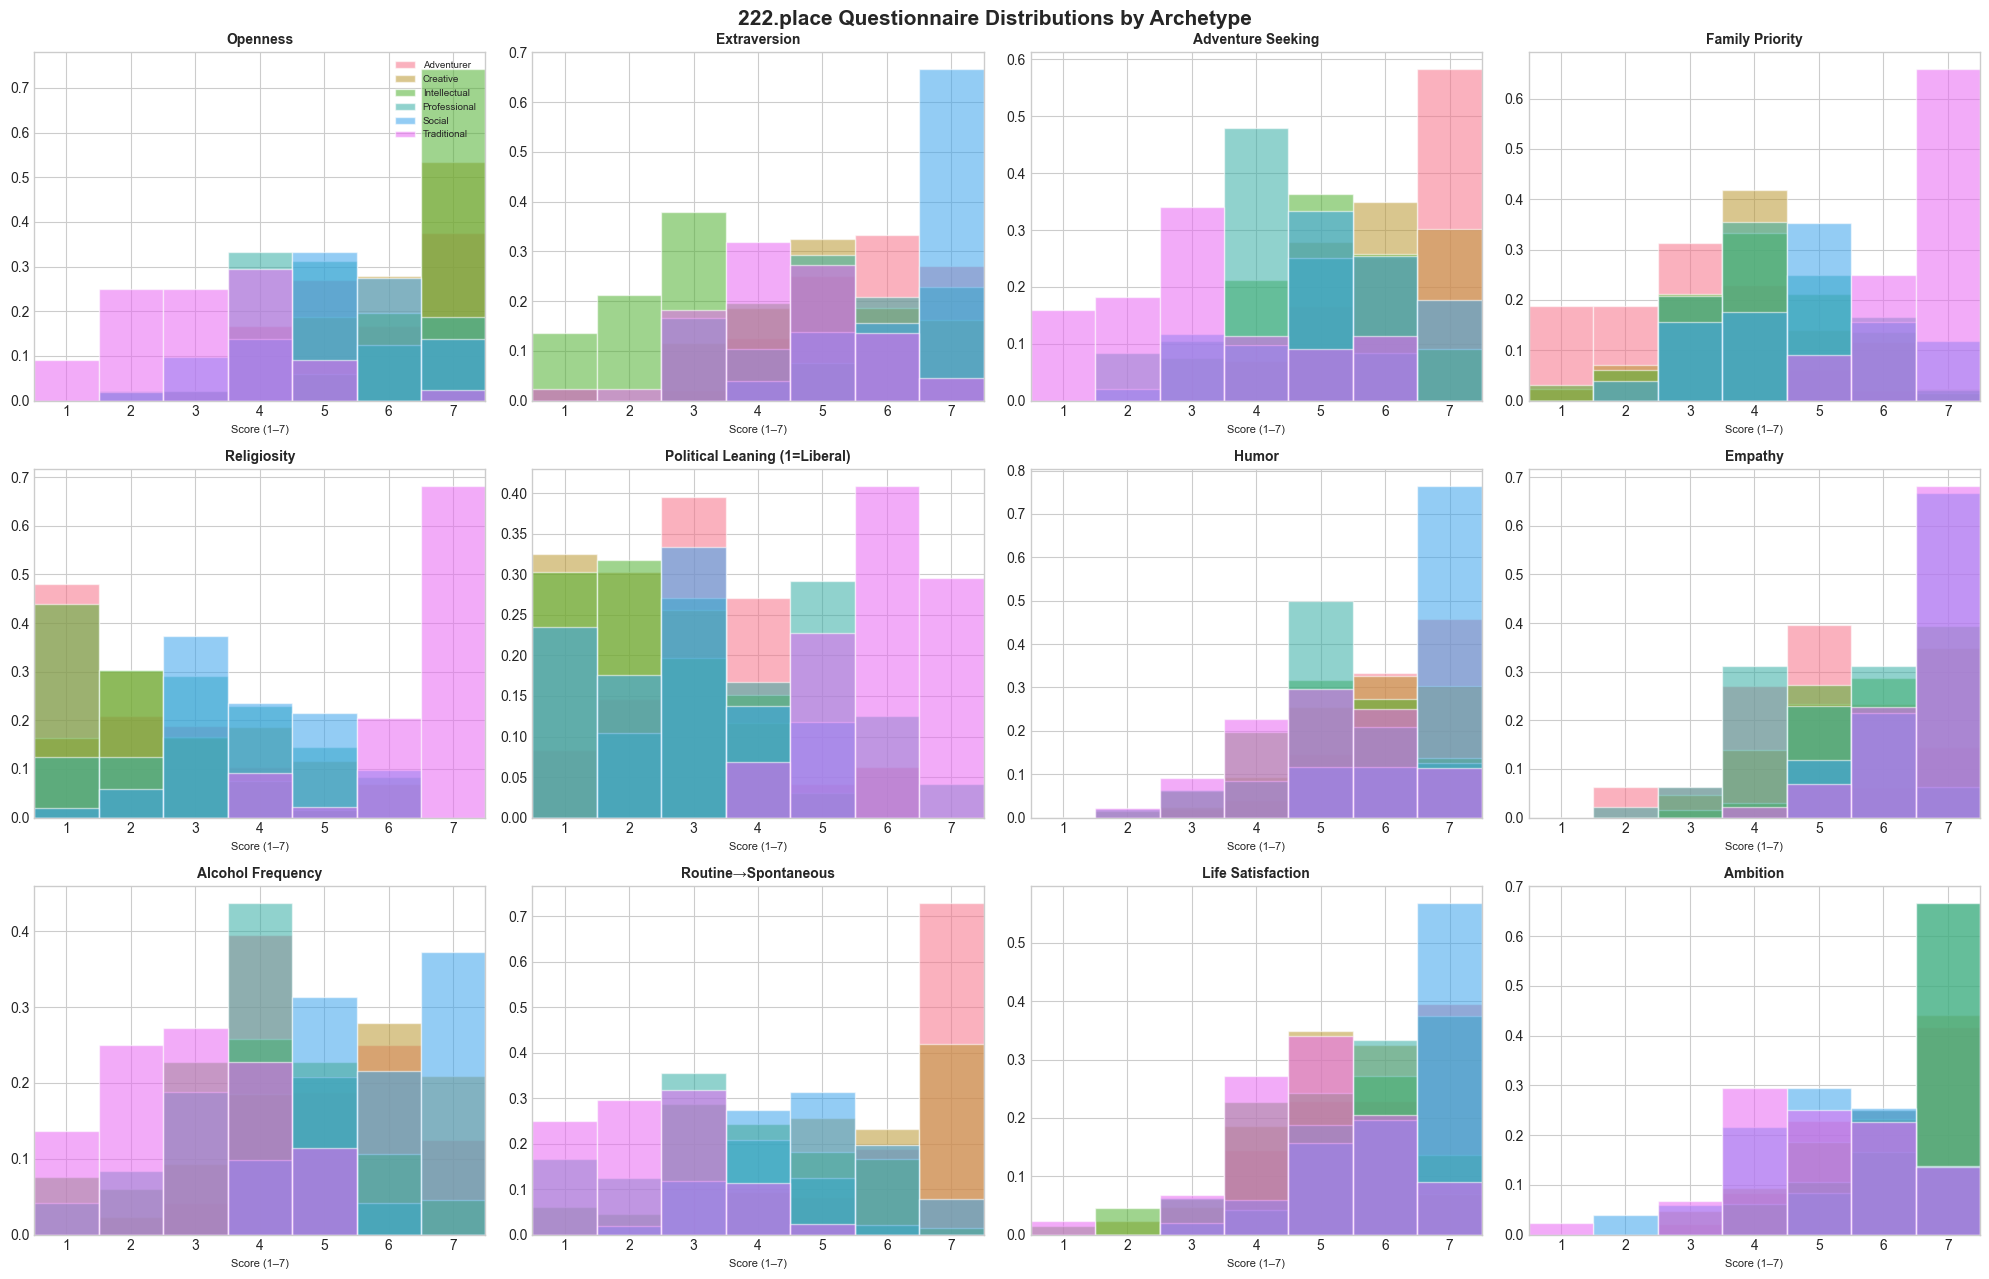

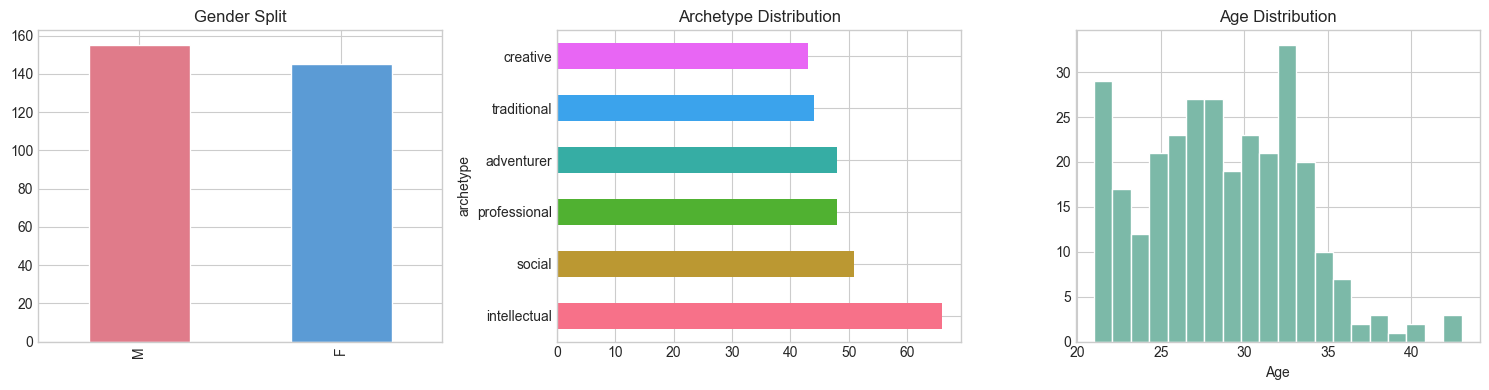

In [4]:
KEY_DIMS = [
    ("personality_openness",          "Openness"),
    ("personality_extraversion",      "Extraversion"),
    ("values_adventure_seeking",      "Adventure Seeking"),
    ("values_family_priority",        "Family Priority"),
    ("religion_religiosity",          "Religiosity"),
    ("perspectives_political_leaning","Political Leaning (1=Liberal)"),
    ("traits_humor",                  "Humor"),
    ("traits_empathy",                "Empathy"),
    ("substances_alcohol_frequency",  "Alcohol Frequency"),
    ("preferences_routine_spontaneous","Routine→Spontaneous"),
    ("self_life_satisfaction",        "Life Satisfaction"),
    ("traits_ambition",               "Ambition"),
]

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle("222.place Questionnaire Distributions by Archetype", fontsize=15, fontweight="bold")
archs = sorted(users.archetype.unique())
palette = sns.color_palette("husl", len(archs))

for ax, (col, label) in zip(axes.flat, KEY_DIMS):
    for arch, color in zip(archs, palette):
        vals = users.loc[users.archetype == arch, col]
        ax.hist(vals, bins=7, range=(.5,7.5), alpha=.55, color=color,
                label=arch.capitalize(), density=True, edgecolor="white")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Score (1–7)", fontsize=8); ax.set_xlim(.5,7.5)

axes[0,0].legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=110, bbox_inches="tight")
plt.show()

# Gender & age distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
users.gender.value_counts().plot.bar(ax=axes[0], color=["#E07B8A","#5B9BD5"],
                                     edgecolor="white", width=.5)
axes[0].set_title("Gender Split"); axes[0].set_xlabel("")

users.archetype.value_counts().plot.barh(ax=axes[1], color=palette)
axes[1].set_title("Archetype Distribution")

axes[2].hist(users.age, bins=20, color="#7CB9A8", edgecolor="white")
axes[2].set_title("Age Distribution"); axes[2].set_xlabel("Age")

plt.tight_layout(); plt.savefig("eda_demographics.png", dpi=110, bbox_inches="tight"); plt.show()


## Feature Engineering

In [5]:
def build_feature_matrix(df):
    """
    Encode all questionnaire fields into a normalised numeric matrix.
    Returns X_scaled (N×F), feature_names, scaler.
    """
    feats, names = [], []

    # 1. 1-7 scale columns (personality … traits)
    scale_cols = [c for c in df.columns
                  if df[c].dtype in [np.int64, np.int32, np.float64]
                  and c not in ["age"]
                  and not c.startswith("pref_cuisine")]
    for col in scale_cols:
        feats.append(df[col].values.astype(float)); names.append(col)

    # 2. Age
    feats.append(df["age"].values.astype(float)); names.append("age")

    # 3. Cuisine preferences
    for col in [c for c in df.columns if c.startswith("pref_cuisine")]:
        feats.append(df[col].values.astype(float)); names.append(col)

    # 4. Education level (ordinal)
    edu_map = {"High School":1,"Some College":2,"Bachelor's":3,"Master's":4,"PhD/Professional":5}
    feats.append(df["education_level"].map(edu_map).values.astype(float))
    names.append("education_level_ord")

    # 5. Education field (one-hot)
    for field in ["STEM","Arts & Humanities","Business","Social Sciences",
                  "Health & Medicine","Law & Policy","Other"]:
        feats.append((df["education_field"] == field).astype(float).values)
        names.append(f"edu_field_{field[:4]}")

    # 6. Media genres (multi-hot)
    for genre in ["Comedy","Drama","Action","Sci-Fi","Romance","Horror",
                  "Documentary","Thriller","Animation","Reality"]:
        feats.append(df["media_genres"].str.contains(genre).astype(float).values)
        names.append(f"genre_{genre}")

    # 7. Hometown size (ordinal)
    hmap = {"Rural":1,"Small Town":2,"Suburban":3,"Urban":4}
    feats.append(df["background_hometown_size"].map(hmap).values.astype(float))
    names.append("hometown_size_ord")

    # 8. Relationship status (one-hot)
    for s in ["Single","Dating","Open Relationship"]:
        feats.append((df["background_relationship_status"] == s).astype(float).values)
        names.append(f"rel_{s[:4].strip()}")

    # 9. Has kids, birth order
    feats.append((df["background_has_kids"] == "Yes").astype(float).values)
    names.append("has_kids")
    for o in ["Only Child","Oldest","Middle","Youngest"]:
        feats.append((df["background_birth_order"] == o).astype(float).values)
        names.append(f"birth_{o[:4]}")

    X = np.column_stack(feats).astype(np.float32)
    scaler = StandardScaler()
    return scaler.fit_transform(X), names, scaler

X, feature_names, scaler = build_feature_matrix(users)
print(f"Feature matrix : {X.shape[0]} users × {X.shape[1]} features")
print(f"Sample names   : {feature_names[:8]} …")


Feature matrix : 300 users × 77 features
Sample names   : ['personality_openness', 'personality_conscientiousness', 'personality_extraversion', 'personality_agreeableness', 'personality_neuroticism', 'religion_religiosity', 'religion_spirituality', 'religion_secular_lean'] …


## ML Model: Numpy Autoencoder

We compress each user's feature vector into a **16-dimensional compatibility embedding**.

```
Encoder:  F → 128 → 64 → 16   (ReLU hidden, linear bottleneck)
Decoder: 16 →  64 → 128 → F   (ReLU hidden, linear output)
Loss:     MSE reconstruction
```

Two users are **compatible** when their embeddings are close (high cosine similarity).


Training autoencoder  [77 → 128 → 64 → 16 → 64 → 128 → 77]
  Epoch  30/180  |  Loss: 0.8050
  Epoch  60/180  |  Loss: 0.6970
  Epoch  90/180  |  Loss: 0.6538
  Epoch 120/180  |  Loss: 0.6289
  Epoch 150/180  |  Loss: 0.6157
  Epoch 180/180  |  Loss: 0.6060


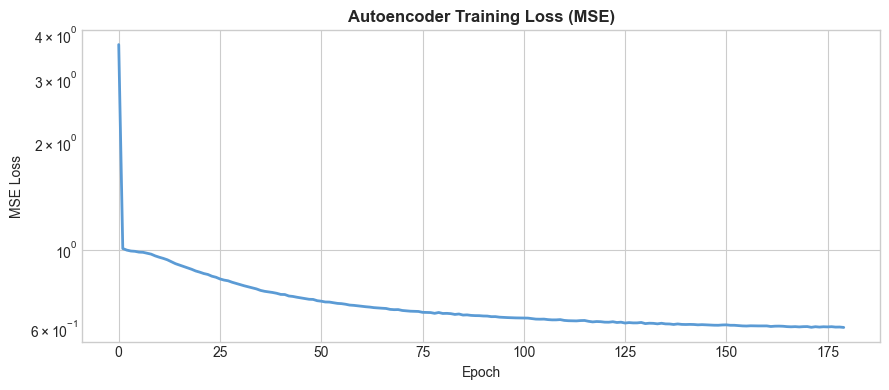

Final loss: 0.6060


In [6]:
def relu(x):       return np.maximum(0, x)
def relu_grad(z):  return (z > 0).astype(np.float32)

class Autoencoder:
    """
    3-layer encoder / decoder implemented in pure NumPy.
    Architecture: [input_dim → h1 → h2 → bottleneck]  (encoder)
                  [bottleneck → h2 → h1 → input_dim]  (decoder)
    """
    def __init__(self, input_dim, h1=128, h2=64, bottleneck=16, lr=5e-3):
        self.lr  = lr
        self.bn  = bottleneck
        dims_enc = [input_dim, h1, h2, bottleneck]
        dims_dec = [bottleneck, h2, h1, input_dim]
        # Initialise with He scaling
        self.We, self.be = [], []
        for a, b in zip(dims_enc, dims_enc[1:]):
            self.We.append(np.random.randn(a, b).astype(np.float32) * np.sqrt(2.0/a))
            self.be.append(np.zeros(b, dtype=np.float32))
        self.Wd, self.bd = [], []
        for a, b in zip(dims_dec, dims_dec[1:]):
            self.Wd.append(np.random.randn(a, b).astype(np.float32) * np.sqrt(2.0/a))
            self.bd.append(np.zeros(b, dtype=np.float32))

    # ── forward ────────────────────────────────────────────────────────────
    def encode(self, X):
        h = X
        for i,(W,b) in enumerate(zip(self.We, self.be)):
            z = h @ W + b
            h = z if i == len(self.We)-1 else relu(z)   # linear bottleneck
        return h

    def forward(self, X):
        cache = {"h_enc":[], "z_enc":[], "h_dec":[], "z_dec":[]}
        h = X
        for i,(W,b) in enumerate(zip(self.We, self.be)):
            z = h @ W + b
            h = z if i == len(self.We)-1 else relu(z)
            cache["z_enc"].append(z); cache["h_enc"].append(h)
        for i,(W,b) in enumerate(zip(self.Wd, self.bd)):
            z = h @ W + b
            h = z if i == len(self.Wd)-1 else relu(z)
            cache["z_dec"].append(z); cache["h_dec"].append(h)
        return h, cache                                # h = x_hat

    # ── backward ────────────────────────────────────────────────────────────
    def backward(self, X, cache):
        n    = len(X)
        x_hat= cache["h_dec"][-1]
        loss = float(np.mean((x_hat - X)**2))

        # Decoder gradients
        dh = 2*(x_hat - X)/n
        grads_Wd, grads_bd = [], []
        h_in = ([cache["h_enc"][-1]] + cache["h_dec"][:-1])
        for i in reversed(range(len(self.Wd))):
            grads_Wd.insert(0, h_in[i].T @ dh)
            grads_bd.insert(0, dh.sum(0))
            dh = dh @ self.Wd[i].T
            if i > 0:
                dh *= relu_grad(cache["z_dec"][i-1])

        # Encoder gradients
        grads_We, grads_be = [], []
        h_in_enc = ([X] + cache["h_enc"][:-1])
        for i in reversed(range(len(self.We))):
            grads_We.insert(0, h_in_enc[i].T @ dh)
            grads_be.insert(0, dh.sum(0))
            dh = dh @ self.We[i].T
            if i > 0:
                dh *= relu_grad(cache["z_enc"][i-1])

        # SGD update with gradient clipping
        clip = 5.0
        for i in range(len(self.We)):
            self.We[i] -= self.lr * np.clip(grads_We[i], -clip, clip)
            self.be[i] -= self.lr * np.clip(grads_be[i], -clip, clip)
        for i in range(len(self.Wd)):
            self.Wd[i] -= self.lr * np.clip(grads_Wd[i], -clip, clip)
            self.bd[i] -= self.lr * np.clip(grads_bd[i], -clip, clip)

        return loss

    # ── training loop ────────────────────────────────────────────────────────
    def fit(self, X, epochs=180, batch_size=64, lr_decay=0.98):
        losses = []
        for epoch in range(epochs):
            self.lr *= lr_decay
            idx = np.random.permutation(len(X))
            batch_losses = []
            for s in range(0, len(X), batch_size):
                b = X[idx[s:s+batch_size]]
                _, cache = self.forward(b)
                batch_losses.append(self.backward(b, cache))
            avg = float(np.mean(batch_losses)); losses.append(avg)
            if (epoch+1) % 30 == 0:
                print(f"  Epoch {epoch+1:3d}/{epochs}  |  Loss: {avg:.4f}")
        return losses


INPUT_DIM = X.shape[1]
ae = Autoencoder(INPUT_DIM, h1=128, h2=64, bottleneck=16, lr=8e-3)
print(f"Training autoencoder  [{INPUT_DIM} → 128 → 64 → 16 → 64 → 128 → {INPUT_DIM}]")
losses = ae.fit(X, epochs=180, batch_size=64, lr_decay=0.985)

plt.figure(figsize=(9,4))
plt.plot(losses, color="#5B9BD5", linewidth=2)
plt.title("Autoencoder Training Loss (MSE)", fontweight="bold")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.yscale("log"); plt.tight_layout()
plt.savefig("training_loss.png", dpi=110); plt.show()
print(f"Final loss: {losses[-1]:.4f}")


## Embeddings & Compatibility Matrix

Embedding shape : (300, 16)
Compatibility matrix: shape=(300, 300)  mean=0.643  std=0.175


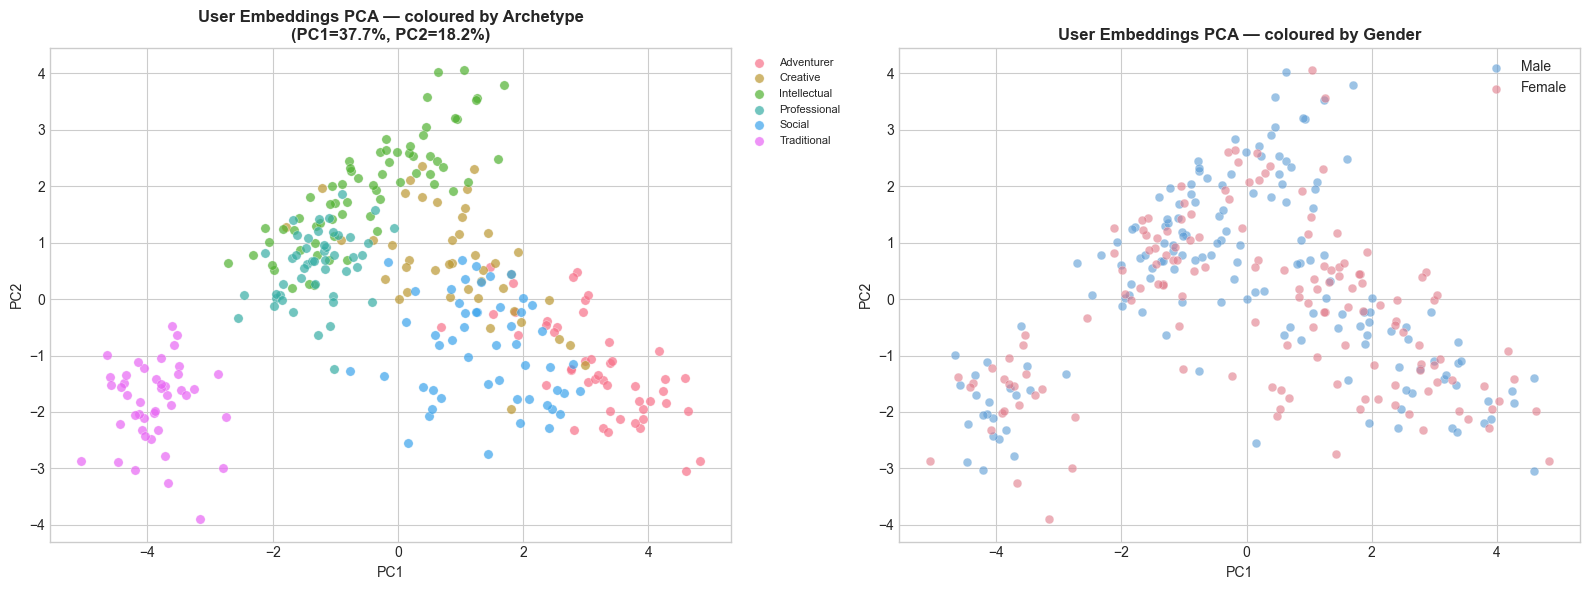

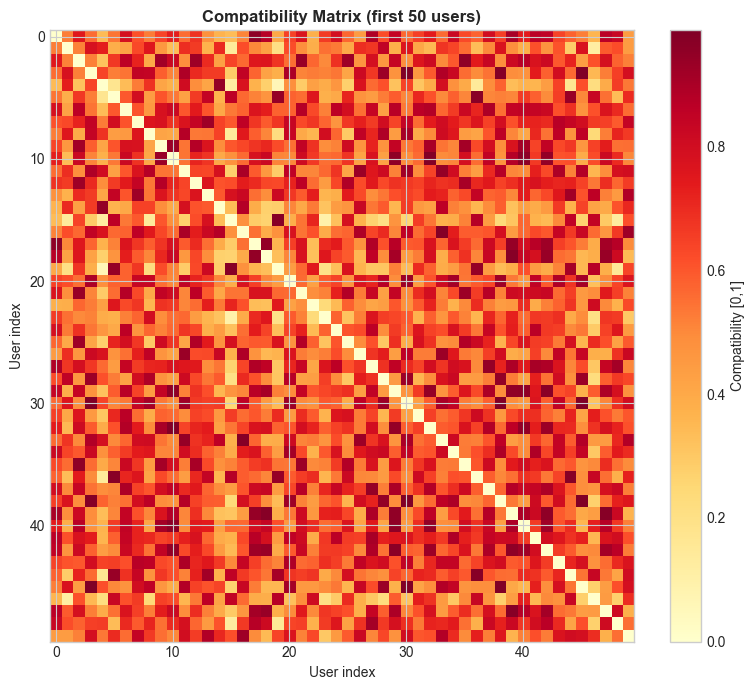

In [7]:
# Extract 16-dim user embeddings
Z = ae.encode(X)                                 # (300, 16)
print(f"Embedding shape : {Z.shape}")

# Cosine similarity → compatibility matrix
raw_sim   = cosine_similarity(Z)                 # (300, 300)
np.fill_diagonal(raw_sim, 0)
# Normalise to [0, 1]
compat = (raw_sim - raw_sim.min()) / (raw_sim.max() - raw_sim.min())
np.fill_diagonal(compat, 0)
print(f"Compatibility matrix: shape={compat.shape}  "
      f"mean={compat.mean():.3f}  std={compat.std():.3f}")

# ── PCA visualisation ──────────────────────────────────────────────────────
pca  = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

archs   = sorted(users.archetype.unique())
palette = sns.color_palette("husl", len(archs))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for arch, color in zip(archs, palette):
    mask = users.archetype == arch
    axes[0].scatter(Z_2d[mask,0], Z_2d[mask,1], c=[color], label=arch.capitalize(),
                    alpha=.7, s=45, edgecolors="white", linewidths=.3)
axes[0].set_title(f"User Embeddings PCA — coloured by Archetype\n"
                  f"(PC1={pca.explained_variance_ratio_[0]:.1%}, "
                  f"PC2={pca.explained_variance_ratio_[1]:.1%})", fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)

for gender, color in zip(["M","F"], ["#5B9BD5","#E07B8A"]):
    mask = users.gender == gender
    axes[1].scatter(Z_2d[mask,0], Z_2d[mask,1], c=color,
                    label="Male" if gender=="M" else "Female",
                    alpha=.6, s=40, edgecolors="white", linewidths=.3)
axes[1].set_title("User Embeddings PCA — coloured by Gender", fontweight="bold")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend()

plt.tight_layout(); plt.savefig("embeddings_pca.png", dpi=110); plt.show()

# Compatibility heatmap (50×50 sample)
fig, ax = plt.subplots(figsize=(8,7))
sample = compat[:50,:50]
im = ax.imshow(sample, cmap="YlOrRd", aspect="auto")
ax.set_title("Compatibility Matrix (first 50 users)", fontweight="bold")
ax.set_xlabel("User index"); ax.set_ylabel("User index")
plt.colorbar(im, ax=ax, label="Compatibility [0,1]")
plt.tight_layout(); plt.savefig("compat_heatmap.png", dpi=110); plt.show()



## Optimisation Problem Formulation

### Sets & Parameters

| Symbol | Description |
|---|---|
| $\mathcal{U}$ | All users partitioned by `user_id` |
| $\mathcal{U}^M, \mathcal{U}^F$ | Male / female subsets |
| $G$ | Number of small groups (size 6) |
| $E$ | Number of large events (~40 ppl = 6–7 groups) |
| $\mathcal{R}$ | Restaurants, each with capacity $\text{cap}_r$ and day set $\mathcal{D}_r$ |
| $c_{ij}$ | Pairwise compatibility score $\in [0,1]$ (autoencoder cosine similarity) |
| $a_{id}$ | 1 if user $i$ is available on day $d$ |

---

### Stage 1 — Group Formation (one ILP per day)

**Decision variables**

$$x_{ig} \in \{0,1\}: \text{ user } i \text{ assigned to group } g$$
$$w_{ijg} \in \{0,1\}: \text{ both user } i \text{ and } j \text{ are in group } g \; (i < j)$$

**Objective — maximise total within-group compatibility**

$$\max \sum_{g=1}^{G}\sum_{(i,j)\,:\,i<j} c_{ij}\cdot w_{ijg}$$

**Constraints**

$$\sum_{g} x_{ig} = 1 \quad \forall i \qquad\text{(C1: each user in exactly one group)}$$
$$\sum_{i} x_{ig} = 6 \quad \forall g \qquad\text{(C2: group size)}$$
$$\sum_{i\in\mathcal{U}^M} x_{ig} = 3,\;\sum_{i\in\mathcal{U}^F} x_{ig} = 3 \quad \forall g \qquad\text{(C3: gender balance)}$$
$$x_{ig} \leq a_{i,d_g} \quad \forall i,g \qquad\text{(C4: day availability)}$$
$$w_{ijg} \leq x_{ig},\; w_{ijg} \leq x_{jg} \quad \forall i{<}j,g \qquad\text{(C5–C6: linearisation UB)}$$
$$w_{ijg} \geq x_{ig}+x_{jg}-1 \quad \forall i{<}j,g \qquad\text{(C7: linearisation LB)}$$

**Complexity**: QIP (quadratic integer programme), NP-hard. We solve exactly for small instances ($N \le 30$, $G \le 5$) and use a **Greedy + Simulated Annealing** heuristic for the full 300-user dataset.

---

### Stage 2 — Event Assembly

**Decision variables**

$$y_{ge} \in \{0,1\}: \text{ group } g \text{ assigned to event } e$$
$$v_{er} \in \{0,1\}: \text{ event } e \text{ held at restaurant } r$$

**Objective — maximise cuisine compatibility**

$$\max \sum_{e}\sum_{r}\sum_{g} \text{cuisine\_match}(g,r)\cdot y_{ge}\cdot v_{er}$$

Linearised as: $\max \sum_{e}\sum_{r} \overline{m}_{er}\cdot v_{er}$ where $\overline{m}_{er}$ = mean cuisine match of groups assigned to $e$ at $r$.

**Constraints**

$$\sum_{e} y_{ge} = 1 \;\forall g, \quad
5 \le \sum_{g} y_{ge} \le 7 \;\forall e, \quad
\sum_{r} v_{er} = 1 \;\forall e$$
$$6\sum_{g} y_{ge} \le \text{cap}_r + M(1-v_{er}) \;\forall e,r \qquad\text{(capacity)}$$
$$v_{er} = 0 \text{ if day} \notin \mathcal{D}_r \qquad\text{(availability)}$$


## Greedy Group Formation + Simulated Annealing

In [8]:
def parse_days(s): return set(s.split("|"))

# ── Greedy group formation ─────────────────────────────────────────────────

def form_groups_greedy(users_df, compat_matrix, embeddings, day, verbose=True):
    """
    Form 6-person groups (3 M + 3 F) from users available on `day`.

    Algorithm
    ---------
    1. Filter users available on `day`; separate by gender.
    2. Seed selection: male with highest mean compatibility to the remaining pool.
    3. Add 2 more males most compatible with the seed.
    4. Add 3 females maximising mean compatibility with the chosen males.
    5. Repeat until no more complete groups can be formed.
    """
    avail_idx = users_df.index[users_df.available_days.apply(
        lambda s: day in parse_days(s))].tolist()

    males   = [i for i in avail_idx if users_df.loc[i, "gender"] == "M"]
    females = [i for i in avail_idx if users_df.loc[i, "gender"] == "F"]
    n_grp   = min(len(males)//3, len(females)//3)
    males   = males[:n_grp*3];  females = females[:n_grp*3]

    if verbose:
        print(f"  {day}: {len(avail_idx)} available  "
              f"({len(males)} M, {len(females)} F)  → {n_grp} groups")

    groups, rem_m, rem_f = [], list(males), list(females)

    while len(rem_m) >= 3 and len(rem_f) >= 3:
        pool = rem_m + rem_f
        # Best seed = male with highest avg compat to pool
        scores = {m: np.mean([compat_matrix[m,j] for j in pool if j!=m]) for m in rem_m[:15]}
        seed   = max(scores, key=scores.get)
        g_m    = [seed]; rem_m.remove(seed)

        # 2 more males most compatible with seed
        m_rank = sorted(rem_m, key=lambda m: -compat_matrix[seed, m])
        for m in m_rank[:2]: g_m.append(m); rem_m.remove(m)

        # 3 females most compatible with group males
        f_rank = sorted(rem_f, key=lambda f: -np.mean([compat_matrix[m,f] for m in g_m]))
        g_f    = f_rank[:3]
        for f in g_f: rem_f.remove(f)

        members  = g_m + g_f
        pair_scores = [compat_matrix[a,b] for a,b in combinations(members,2)]
        groups.append({"members":members,"males":g_m,"females":g_f,
                       "avg_compat":float(np.mean(pair_scores))})

    return groups


# ── Simulated Annealing refinement ─────────────────────────────────────────

def sa_refine(groups, compat_matrix, n_iter=3000, T_init=0.05, T_final=0.001):
    """
    Improve group assignments with simulated annealing.
    At each step: randomly pick two groups, randomly swap one same-gender pair.
    """
    import copy
    groups = copy.deepcopy(groups)

    def total_score(gs):
        return sum(np.mean([compat_matrix[a,b] for a,b in combinations(g["members"],2)])
                   for g in gs)

    cur  = total_score(groups)
    best = cur; best_groups = copy.deepcopy(groups)
    alpha = (T_final/T_init)**(1/n_iter)
    T = T_init

    for _ in range(n_iter):
        if len(groups) < 2: break
        g1i, g2i = np.random.choice(len(groups), 2, replace=False)
        gender    = np.random.choice(["M","F"])
        pool1 = groups[g1i]["males"] if gender=="M" else groups[g1i]["females"]
        pool2 = groups[g2i]["males"] if gender=="M" else groups[g2i]["females"]
        if not pool1 or not pool2: T*=alpha; continue

        u1 = np.random.choice(pool1); u2 = np.random.choice(pool2)
        # Compute delta without full recompute
        old_m1 = groups[g1i]["members"]; old_m2 = groups[g2i]["members"]
        new_m1 = [u2 if x==u1 else x for x in old_m1]
        new_m2 = [u1 if x==u2 else x for x in old_m2]
        delta = (np.mean([compat_matrix[a,b] for a,b in combinations(new_m1,2)]) +
                 np.mean([compat_matrix[a,b] for a,b in combinations(new_m2,2)])) -                 (np.mean([compat_matrix[a,b] for a,b in combinations(old_m1,2)]) +
                 np.mean([compat_matrix[a,b] for a,b in combinations(old_m2,2)]))

        if delta > 0 or np.random.random() < np.exp(delta / T):
            key = "males" if gender=="M" else "females"
            groups[g1i]["members"] = new_m1
            groups[g2i]["members"] = new_m2
            groups[g1i][key] = [u2 if x==u1 else x for x in pool1]
            groups[g2i][key] = [u1 if x==u2 else x for x in pool2]
            cur += delta
            if cur > best: best = cur; best_groups = copy.deepcopy(groups)
        T *= alpha

    # Recompute final scores
    for g in best_groups:
        g["avg_compat"] = float(np.mean(
            [compat_matrix[a,b] for a,b in combinations(g["members"],2)]))
    print(f"    SA done  |  avg compat: {np.mean([g['avg_compat'] for g in best_groups]):.4f}")
    return best_groups


## Exact ILP — Small Instance Demo (scipy `milp`)

In [9]:
def solve_ilp(user_indices, compat_matrix, users_df, n_groups=5, time_limit=90):
    """
    Exact ILP for a small subset of users.
    Variables:
        x[i,g]   ∈ {0,1}  —  user i assigned to group g
        w[p,g]   ∈ {0,1}  —  both users in pair p are in group g
    Objective:  minimize  -∑_{p,g} c_p * w[p,g]   (maximise compatibility)
    """
    from scipy.sparse import lil_matrix

    N  = len(user_indices)
    G  = n_groups
    assert N == G * 6, f"Need exactly {G*6} users, got {N}"

    pairs = list(combinations(range(N), 2))
    P     = len(pairs)
    n_x   = N * G        # x variables
    n_w   = P * G        # w variables
    n_var = n_x + n_w

    xi = lambda i,g: i*G + g          # x[i,g] index
    wi = lambda p,g: n_x + p*G + g    # w[p,g] index

    # Objective vector
    c_obj = np.zeros(n_var)
    for pi,(i,j) in enumerate(pairs):
        oi, oj = user_indices[i], user_indices[j]
        for g in range(G):
            c_obj[wi(pi,g)] = -float(compat_matrix[oi,oj])

    # ── Constraint matrix ────────────────────────────────────────────────────
    n_c = N + G + 2*G + 3*P*G          # C1 + C2 + C3/C4 + C5+C6+C7
    A   = lil_matrix((n_c, n_var), dtype=np.float64)
    lb  = np.full(n_c, -np.inf); ub = np.zeros(n_c)
    row = 0

    males   = [k for k,oi in enumerate(user_indices) if users_df.loc[oi,"gender"]=="M"]
    females = [k for k,oi in enumerate(user_indices) if users_df.loc[oi,"gender"]=="F"]

    # C1: ∑_g x[i,g] = 1
    for i in range(N):
        for g in range(G): A[row, xi(i,g)] = 1
        lb[row] = ub[row] = 1; row += 1

    # C2: ∑_i x[i,g] = 6
    for g in range(G):
        for i in range(N): A[row, xi(i,g)] = 1
        lb[row] = ub[row] = 6; row += 1

    # C3/C4: gender balance 3+3
    for g in range(G):
        for i in males:   A[row, xi(i,g)] = 1
        lb[row] = ub[row] = 3; row += 1
        for i in females: A[row, xi(i,g)] = 1
        lb[row] = ub[row] = 3; row += 1

    # C5: w[p,g] - x[i,g] ≤ 0
    for pi,(i,j) in enumerate(pairs):
        for g in range(G):
            A[row, wi(pi,g)] = 1; A[row, xi(i,g)] = -1
            ub[row] = 0; row += 1

    # C6: w[p,g] - x[j,g] ≤ 0
    for pi,(i,j) in enumerate(pairs):
        for g in range(G):
            A[row, wi(pi,g)] = 1; A[row, xi(j,g)] = -1
            ub[row] = 0; row += 1

    # C7: -w[p,g] + x[i,g] + x[j,g] ≤ 1
    for pi,(i,j) in enumerate(pairs):
        for g in range(G):
            A[row, wi(pi,g)] = -1; A[row, xi(i,g)] = 1; A[row, xi(j,g)] = 1
            ub[row] = 1; row += 1

    print(f"  ILP size: {n_var} variables, {n_c} constraints")

    res = milp(
        c         = c_obj,
        integrality = np.ones(n_var),
        bounds    = Bounds(lb=np.zeros(n_var), ub=np.ones(n_var)),
        constraints = LinearConstraint(A.tocsr(), lb, ub),
        options   = {"time_limit": time_limit, "disp": False}
    )

    print(f"  Status: {res.message}")
    print(f"  Objective (total compat): {-res.fun:.4f}")

    x_vals = (res.x[:n_x].reshape(N, G) > 0.5)
    groups = []
    for g in range(G):
        local_members = [k for k in range(N) if x_vals[k,g]]
        orig_members  = [user_indices[k] for k in local_members]
        m_list = [user_indices[k] for k in local_members if users_df.loc[user_indices[k],"gender"]=="M"]
        f_list = [user_indices[k] for k in local_members if users_df.loc[user_indices[k],"gender"]=="F"]
        ps = [compat_matrix[a,b] for a,b in combinations(orig_members,2)]
        groups.append({"group_id":g,"members":orig_members,"males":m_list,
                       "females":f_list,"avg_compat":float(np.mean(ps)) if ps else 0})
    return groups


# ── Run on a 30-user subset (balanced M/F) ───────────────────────────────────
print("Running exact ILP on a 30-user (15 M + 15 F) subset …")
m_idx = users.index[users.gender=="M"].tolist()[:15]
f_idx = users.index[users.gender=="F"].tolist()[:15]
subset_idx = m_idx + f_idx

ilp_groups, ilp_obj = solve_ilp(subset_idx, compat, users, n_groups=5), None

print("\n--- ILP Groups ---")
for g in ilp_groups:
    mnames = [users.loc[m,"user_id"] for m in g["members"]]
    print(f"  Group {g['group_id']+1}: {mnames}  |  compat={g['avg_compat']:.3f}")


Running exact ILP on a 30-user (15 M + 15 F) subset …
  ILP size: 2325 variables, 6570 constraints
  Status: Time limit reached. (HiGHS Status 13: Time limit reached)
  Objective (total compat): 49.1692

--- ILP Groups ---
  Group 1: ['U0023', 'U0027', 'U0031', 'U0004', 'U0012', 'U0021']  |  compat=0.752
  Group 2: ['U0001', 'U0006', 'U0030', 'U0002', 'U0009', 'U0018']  |  compat=0.590
  Group 3: ['U0011', 'U0019', 'U0029', 'U0008', 'U0010', 'U0013']  |  compat=0.693
  Group 4: ['U0005', 'U0017', 'U0025', 'U0015', 'U0024', 'U0026']  |  compat=0.531
  Group 5: ['U0007', 'U0016', 'U0020', 'U0003', 'U0014', 'U0022']  |  compat=0.712


## Full Pipeline — All Days (Greedy + SA)

In [10]:
DAYS_TO_RUN = ["Thursday","Friday","Saturday","Sunday"]
all_day_groups = {}

for day in DAYS_TO_RUN:
    print(f"\n{'='*50}  {day}")
    grps = form_groups_greedy(users, compat, Z, day=day, verbose=True)
    if len(grps) < 2:
        print("  Not enough balanced users — skipping"); continue
    print(f"  Greedy: {len(grps)} groups  |  "
          f"avg compat = {np.mean([g['avg_compat'] for g in grps]):.4f}")
    grps = sa_refine(grps, compat, n_iter=3000)
    all_day_groups[day] = grps

print("\n" + "="*60)
print(f"TOTAL GROUPS FORMED : {sum(len(v) for v in all_day_groups.values())}")
print(f"TOTAL USERS PLACED  : {sum(sum(len(g['members']) for g in v) for v in all_day_groups.values())}")



==================================================  Thursday
  Thursday: 119 available  (51 M, 51 F)  → 17 groups
  Greedy: 17 groups  |  avg compat = 0.8430
    SA done  |  avg compat: 0.8444

==================================================  Friday
  Friday: 124 available  (60 M, 60 F)  → 20 groups
  Greedy: 20 groups  |  avg compat = 0.8278
    SA done  |  avg compat: 0.8352

==================================================  Saturday
  Saturday: 137 available  (63 M, 63 F)  → 21 groups
  Greedy: 21 groups  |  avg compat = 0.8356
    SA done  |  avg compat: 0.8356

==================================================  Sunday
  Sunday: 129 available  (63 M, 63 F)  → 21 groups
  Greedy: 21 groups  |  avg compat = 0.8386
    SA done  |  avg compat: 0.8386

TOTAL GROUPS FORMED : 79
TOTAL USERS PLACED  : 474


## Event Assembly — Groups → Events → Restaurants

In [12]:
def cuisine_score(group_members, rest_row):
    """Average user preference for restaurant cuisine (normalised to [0,1])."""
    col = f"pref_cuisine_{rest_row['cuisine'].lower()}"
    if col in users.columns:
        return float(users.loc[group_members, col].mean()) / 7.0
    return 0.5


def assemble_events(groups, restaurants_df, day,
                    min_grp=5, max_grp=7, time_limit=30):
    """
    Assign groups to events and events to restaurants using scipy milp.
    Objective: maximise sum of (group avg_compat × cuisine match).
    """
    from scipy.sparse import lil_matrix

    avail_rest = restaurants_df[
        restaurants_df.available_days.apply(lambda s: day in s.split("|"))
    ].copy()

    NG = len(groups)
    NE = max(1, NG // 6)          # target 6 groups per event
    NR = len(avail_rest)

    if NG == 0 or NR == 0:
        return []

    R_idx = avail_rest.index.tolist()
    # Pre-compute group×restaurant cuisine scores
    gr_score = {(g,r): cuisine_score(groups[g]["members"], avail_rest.loc[r])
                for g in range(NG) for r in R_idx}

    # Variable layout: y[g,e] then v[e,r]
    n_y  = NG * NE
    n_v  = NE * NR
    n_var = n_y + n_v
    yi = lambda g,e: g*NE + e
    vi = lambda e,r: n_y + e*NR + R_idx.index(r)

    # Objective: maximise ∑_{g,e,r} compat(g) * cuisine(g,r) * y[g,e]*v[e,r]
    # Linearise: ∑_g avg_compat(g)*y[g,e] + ∑_{e,r} cuisine_avg_er * v[e,r]  (heuristic)
    c_obj = np.zeros(n_var)
    for g in range(NG):
        for e in range(NE):
            c_obj[yi(g,e)] = -groups[g]["avg_compat"]          # negate = minimise
    for e in range(NE):
        for r in R_idx:
            avg_cs = np.mean([gr_score[(g,r)] for g in range(NG)])
            c_obj[vi(e,r)] -= 0.3 * avg_cs

    # Constraints
    nC = NG + 2*NE + NE + NE*NR
    A  = lil_matrix((nC, n_var)); lb = np.full(nC,-np.inf); ub = np.zeros(nC); row = 0

    # C1: ∑_e y[g,e] = 1 ∀g
    for g in range(NG):
        for e in range(NE): A[row, yi(g,e)] = 1
        lb[row] = ub[row] = 1; row += 1

    # C2/C3: min_grp ≤ ∑_g y[g,e] ≤ max_grp
    for e in range(NE):
        for g in range(NG): A[row, yi(g,e)] = 1
        lb[row] = min_grp; ub[row] = max_grp; row += 1
        for g in range(NG): A[row, yi(g,e)] = -1
        ub[row] = -min_grp; lb[row] = -max_grp; row += 1

    # C4: ∑_r v[e,r] = 1 ∀e
    for e in range(NE):
        for r in R_idx: A[row, vi(e,r)] = 1
        lb[row] = ub[row] = 1; row += 1

    # C5: 6*∑_g y[g,e] ≤ cap(r) + M*(1-v[e,r])  →  6*∑y - cap*v ≤ M*(1 - v)
    # Relaxed linear form: 6*∑_g y[g,e] ≤ cap(r) * v[e,r] + M*(1-v[e,r])
    BIG_M = NG * 6
    for e in range(NE):
        for r in R_idx:
            cap = avail_rest.loc[r,"capacity"]
            for g in range(NG): A[row, yi(g,e)] = 6
            A[row, vi(e,r)] = -cap
            ub[row] = BIG_M; lb[row] = -np.inf; row += 1

    res = milp(c=c_obj, integrality=np.ones(n_var),
               bounds=Bounds(lb=np.zeros(n_var), ub=np.ones(n_var)),
               constraints=LinearConstraint(A.tocsr(), lb, ub),
               options={"time_limit": time_limit, "disp": False})

    # Extract solution
    y_val = (res.x[:n_y].reshape(NG, NE) > 0.5) if res.success else np.zeros((NG,NE), bool)
    v_val = (res.x[n_y:].reshape(NE, NR) > 0.5) if res.success else np.zeros((NE,NR), bool)

    events = []
    for e in range(NE):
        evt_groups = [groups[g] for g in range(NG) if y_val[g,e]]
        r_idx_local = next((k for k in range(NR) if v_val[e,k]), 0)
        rest_row   = avail_rest.iloc[r_idx_local]
        all_mbrs   = [m for g in evt_groups for m in g["members"]]
        events.append({
            "event_id":    f"{day[:3].upper()}_E{e+1}",
            "day":         day,
            "n_groups":    len(evt_groups),
            "n_attendees": len(all_mbrs),
            "groups":      evt_groups,
            "restaurant":  rest_row["name"],
            "cuisine":     rest_row["cuisine"],
            "capacity":    int(rest_row["capacity"]),
            "all_members": all_mbrs,
        })
    return events


# ── Run event assembly for all days ──────────────────────────────────────────
all_events = {}
for day, grps in all_day_groups.items():
    print(f"\nAssembling events for {day} …")
    evts = assemble_events(grps, restaurants, day)
    all_events[day] = evts

print("\n" + "="*60)
print("🍽️  222.place EVENT SCHEDULE")
print("="*60)
for day, evts in all_events.items():
    print(f"\n📅  {day.upper()}")
    for evt in evts:
        print(f"  {evt['event_id']}  |  {evt['restaurant']} ({evt['cuisine']})"
              f"  |  {evt['n_attendees']} people / {evt['n_groups']} tables")



Assembling events for Thursday …

Assembling events for Friday …

Assembling events for Saturday …

Assembling events for Sunday …

🍽️  222.place EVENT SCHEDULE

📅  THURSDAY
  THU_E1  |  Osteria Romana (Italian)  |  0 people / 0 tables
  THU_E2  |  Osteria Romana (Italian)  |  0 people / 0 tables

📅  FRIDAY
  FRI_E1  |  Riviera Grill (Mediterranean)  |  42 people / 7 tables
  FRI_E2  |  Riviera Grill (Mediterranean)  |  42 people / 7 tables
  FRI_E3  |  Riviera Grill (Mediterranean)  |  36 people / 6 tables

📅  SATURDAY
  SAT_E1  |  Verde Olivo (Mediterranean)  |  42 people / 7 tables
  SAT_E2  |  Verde Olivo (Mediterranean)  |  42 people / 7 tables
  SAT_E3  |  Verde Olivo (Mediterranean)  |  42 people / 7 tables

📅  SUNDAY
  SUN_E1  |  Umami Bar (Japanese)  |  42 people / 7 tables
  SUN_E2  |  Umami Bar (Japanese)  |  42 people / 7 tables
  SUN_E3  |  Umami Bar (Japanese)  |  42 people / 7 tables


## Results & Visualisation

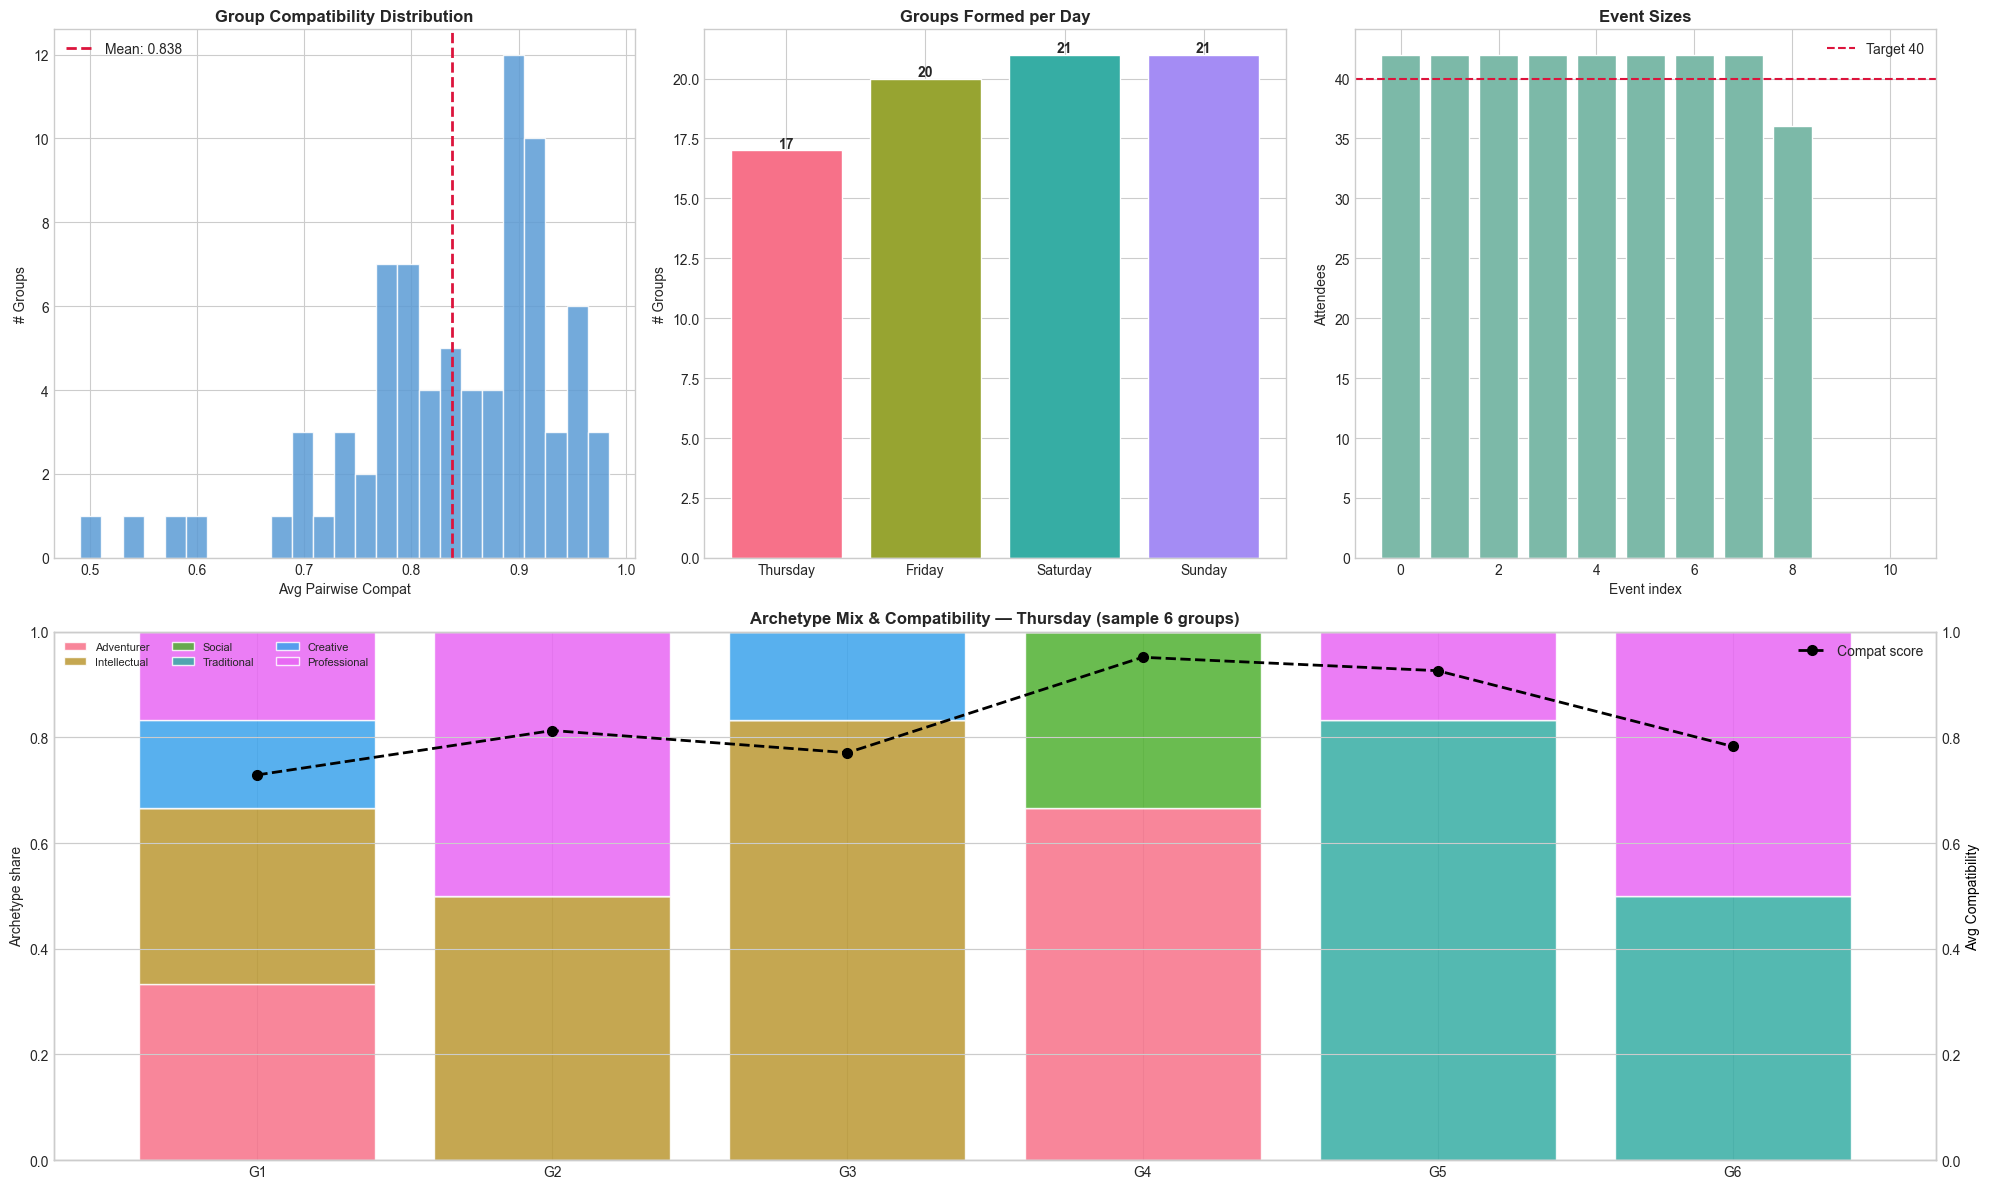


🏆 HIGHEST COMPATIBILITY GROUP
  U0088  M  36y  Traditional     Open=3  Extra=4  Humor=4  Empathy=7
  U0082  M  29y  Traditional     Open=3  Extra=5  Humor=5  Empathy=7
  U0171  M  33y  Traditional     Open=3  Extra=3  Humor=4  Empathy=7
  U0248  F  34y  Professional    Open=6  Extra=7  Humor=5  Empathy=4
  U0194  F  35y  Traditional     Open=4  Extra=4  Humor=5  Empathy=5
  U0285  F  26y  Traditional     Open=2  Extra=3  Humor=6  Empathy=7

  Avg pairwise compatibility: 0.9841


In [21]:
# ── 1. Compatibility score distributions ─────────────────────────────────────
all_scores = [g["avg_compat"] for grps in all_day_groups.values() for g in grps]

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(all_scores, bins=25, color="#5B9BD5", edgecolor="white", alpha=.85)
ax1.axvline(np.mean(all_scores), color="crimson", ls="--", lw=2,
            label=f"Mean: {np.mean(all_scores):.3f}")
ax1.set_title("Group Compatibility Distribution", fontweight="bold")
ax1.set_xlabel("Avg Pairwise Compat"); ax1.set_ylabel("# Groups"); ax1.legend()

# ── 2. Groups per day ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
days_plot = list(all_day_groups.keys())
gcounts   = [len(all_day_groups[d]) for d in days_plot]
colors    = sns.color_palette("husl", len(days_plot))
bars = ax2.bar(days_plot, gcounts, color=colors, edgecolor="white")
ax2.set_title("Groups Formed per Day", fontweight="bold")
ax2.set_ylabel("# Groups")
for bar,v in zip(bars,gcounts): ax2.text(bar.get_x()+bar.get_width()/2, v+.1,
                                          str(v), ha="center", fontweight="bold")

# ── 3. Event sizes ────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
evt_sizes = [e["n_attendees"] for evts in all_events.values() for e in evts]
if evt_sizes:
    ax3.bar(range(len(evt_sizes)), sorted(evt_sizes, reverse=True),
            color="#7CB9A8", edgecolor="white")
    ax3.axhline(40, color="crimson", ls="--", lw=1.5, label="Target 40")
    ax3.set_title("Event Sizes", fontweight="bold")
    ax3.set_xlabel("Event index"); ax3.set_ylabel("Attendees"); ax3.legend()

# ── 4. Sample group spotlight ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
best_day   = max(all_day_groups, key=lambda d: np.mean([g["avg_compat"] for g in all_day_groups[d]]))
best_groups= all_day_groups[best_day][:6]   # first 6 groups of best day
group_labels   = [f"G{i+1}" for i in range(len(best_groups))]
group_scores   = [g["avg_compat"] for g in best_groups]
arch_breakdown = {}
ARCHETYPES = ["adventurer", "intellectual", "social", "traditional", "creative", "professional"]

for arch in ARCHETYPES:
    arch_breakdown[arch] = [
        sum(1 for m in g["members"] if users.loc[m,"archetype"]==arch)/6
        for g in best_groups]

bottom = np.zeros(len(best_groups))
pal    = sns.color_palette("husl", 6)
for arch,color in zip(ARCHETYPES,pal):
    vals = arch_breakdown[arch]
    ax4.bar(group_labels, vals, bottom=bottom, color=color, label=arch.capitalize(),
            edgecolor="white", alpha=.85)
    bottom += np.array(vals)

ax4_twin = ax4.twinx()
ax4_twin.plot(group_labels, group_scores, "ko--", ms=7, lw=2, label="Compat score")
ax4_twin.set_ylabel("Avg Compatibility", color="black")
ax4_twin.set_ylim(0, 1)
ax4.set_title(f"Archetype Mix & Compatibility — {best_day} (sample 6 groups)",
              fontweight="bold")
ax4.set_ylabel("Archetype share"); ax4.legend(loc="upper left", ncol=3, fontsize=8)
ax4_twin.legend(loc="upper right")

plt.tight_layout(); plt.savefig("results_overview.png", dpi=110, bbox_inches="tight"); plt.show()

# ── Print sample group ─────────────────────────────────────────────────────────
top_group = max((g for grps in all_day_groups.values() for g in grps),
                key=lambda g: g["avg_compat"])
print("\n🏆 HIGHEST COMPATIBILITY GROUP")
print("="*55)
for m in top_group["members"]:
    u = users.loc[m]
    print(f"  {u['user_id']}  {u['gender']}  {u['age']}y  {u['archetype'].capitalize():<14s}"
          f"  Open={u['personality_openness']}  Extra={u['personality_extraversion']}"
          f"  Humor={u['traits_humor']}  Empathy={u['traits_empathy']}")
print(f"\n  Avg pairwise compatibility: {top_group['avg_compat']:.4f}")


## Export Final Event Schedule

In [22]:
schedule_rows = []
for day, evts in all_events.items():
    for evt in evts:
        for gi, grp in enumerate(evt["groups"]):
            for member in grp["members"]:
                u = users.loc[member]
                schedule_rows.append({
                    "event_id":    evt["event_id"],
                    "day":         day,
                    "restaurant":  evt["restaurant"],
                    "cuisine":     evt["cuisine"],
                    "n_attendees": evt["n_attendees"],
                    "table_number":gi+1,
                    "user_id":     u["user_id"],
                    "gender":      u["gender"],
                    "age":         u["age"],
                    "archetype":   u["archetype"],
                    "table_compat":round(grp["avg_compat"],4),
                })

schedule_df = pd.DataFrame(schedule_rows)
schedule_df.to_csv("222_event_schedule.csv", index=False)
print(f"Exported {len(schedule_df)} rows to 222_event_schedule.csv")
print(f"Events: {schedule_df.event_id.nunique()}")
print(f"Users placed: {schedule_df.user_id.nunique()}")
print()
schedule_df.head(12)


Exported 372 rows to 222_event_schedule.csv
Events: 9
Users placed: 246



,event_id,day,restaurant,cuisine,n_attendees,table_number,user_id,gender,age,archetype,table_compat
0,FRI_E1,Friday,Riviera Grill,Mediterranean,42,1,U0211,M,29,social,0.8457
1,FRI_E1,Friday,Riviera Grill,Mediterranean,42,1,U0224,M,32,social,0.8457
2,FRI_E1,Friday,Riviera Grill,Mediterranean,42,1,U0231,M,35,creative,0.8457
3,FRI_E1,Friday,Riviera Grill,Mediterranean,42,1,U0277,F,26,creative,0.8457
4,FRI_E1,Friday,Riviera Grill,Mediterranean,42,1,U0018,F,27,social,0.8457
5,FRI_E1,Friday,Riviera Grill,Mediterranean,42,1,U0161,F,23,social,0.8457
6,FRI_E1,Friday,Riviera Grill,Mediterranean,42,2,U0213,M,30,traditional,0.9340
7,FRI_E1,Friday,Riviera Grill,Mediterranean,42,2,U0249,M,33,professional,0.9340
8,FRI_E1,Friday,Riviera Grill,Mediterranean,42,2,U0029,M,23,traditional,0.9340
9,FRI_E1,Friday,Riviera Grill,Mediterranean,42,2,U0055,F,34,traditional,0.9340
